# Global Market Shock Analysis (2020–Present)

This project analyzes how major global financial markets reacted to economic shocks since 2020.

The analysis focuses on several key assets:

- S&P 500 (equity market)
- Gold (safe-haven asset)
- WTI crude oil (energy market)
- EUR/USD exchange rate
- EUR/PLN and USD/PLN exchange rates

The goal is to understand how different asset classes respond to major global events such as the COVID-19 pandemic, inflation shocks, and monetary policy changes.

The analysis is performed using Python with pandas, matplotlib, and seaborn.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

import pandas_datareader.data as web
from datetime import datetime

plt.style.use("seaborn-v0_8")

## Data Collection

We download historical price data for several major financial assets using the yfinance API.

In [19]:
symbols = {
    "EURUSD": "EURUSD=X",
    "GOLD": "GC=F",
    "WTI": "CL=F",
    "SP500": "^GSPC",
    "EURPLN": "EURPLN=X",
    "USDPLN": "USDPLN=X"
}

start = "2020-01-01"

data = {}

for name, ticker in symbols.items():

    df = yf.download(ticker, start=start, progress=False)

    # Check if data exists
    if df.empty:
        print(f"No data for {name}")
        continue

    # Store close prices
    data[name] = df["Close"]

# Combine into one dataframe
prices = pd.concat(data, axis=1)

# Remove rows with missing values
prices = prices.dropna()

# Check data
prices.head()

,EURUSD,GOLD,WTI,SP500,EURPLN,USDPLN
Ticker,EURUSD=X,GC=F,CL=F,^GSPC,EURPLN=X,USDPLN=X
Date,,,,,,
2020-01-02,1.122083,1524.500000,61.180000,3257.850098,4.25540,3.79300
2020-01-03,1.117144,1549.199951,63.049999,3234.850098,4.23840,3.79400
2020-01-06,1.116196,1566.199951,63.270000,3246.280029,4.24238,3.80104
2020-01-07,1.119799,1571.800049,62.700001,3237.179932,4.23080,3.77950
2020-01-08,1.115474,1557.400024,59.610001,3253.050049,4.24601,3.80685


## Data Source

Financial market data is downloaded using the **yfinance** API, which provides historical price data from Yahoo Finance.

The dataset includes daily prices starting from 2020.

## Market Overview

To compare assets with different price levels we normalize them to a base value of 100.

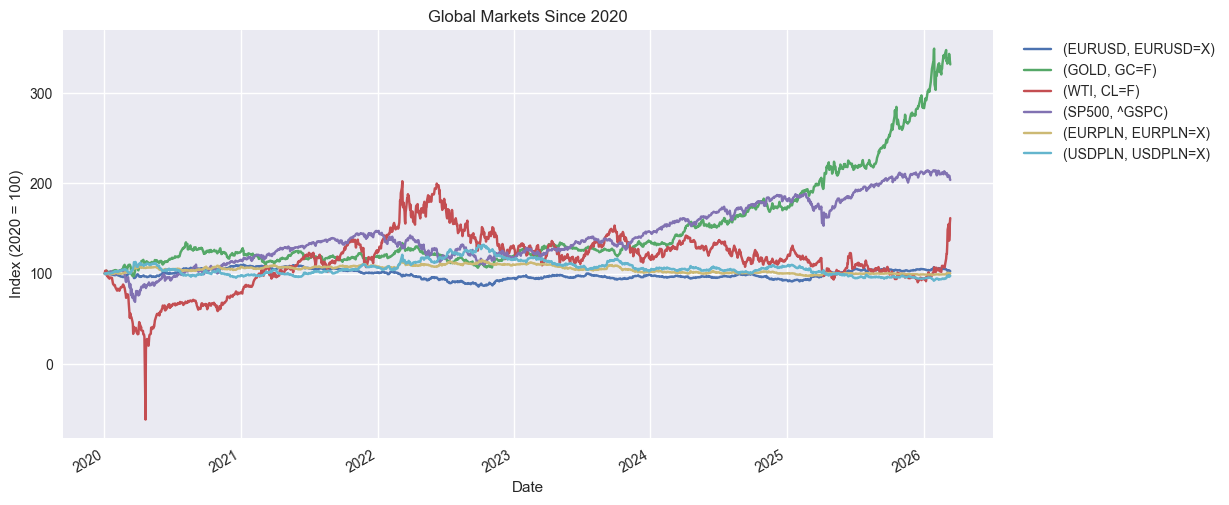

In [42]:
normalized.plot(figsize=(12,6))

plt.title("Global Markets Since 2020")
plt.ylabel("Index (2020 = 100)")
plt.xlabel("Date")

plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.grid(True)

In [44]:
returns = prices.pct_change().dropna()
returns.head()
returns.describe().round(4)

,EURUSD,GOLD,WTI,SP500,EURPLN,USDPLN
Ticker,EURUSD=X,GC=F,CL=F,^GSPC,EURPLN=X,USDPLN=X
count,1555.0000,1555.0000,1555.0000,1555.0000,1555.0000,1555.0000
mean,0.0000,0.0008,-0.0016,0.0005,0.0000,0.0000
std,0.0048,0.0115,0.0900,0.0130,0.0040,0.0070
min,-0.0278,-0.1137,-3.0597,-0.1198,-0.0208,-0.0362
25%,-0.0027,-0.0045,-0.0135,-0.0048,-0.0021,-0.0042
50%,-0.0001,0.0011,0.0018,0.0009,-0.0002,-0.0001
75%,0.0029,0.0069,0.0153,0.0067,0.0019,0.0039
max,0.0279,0.0608,0.3766,0.0952,0.0246,0.0430


## Correlation Between Assets

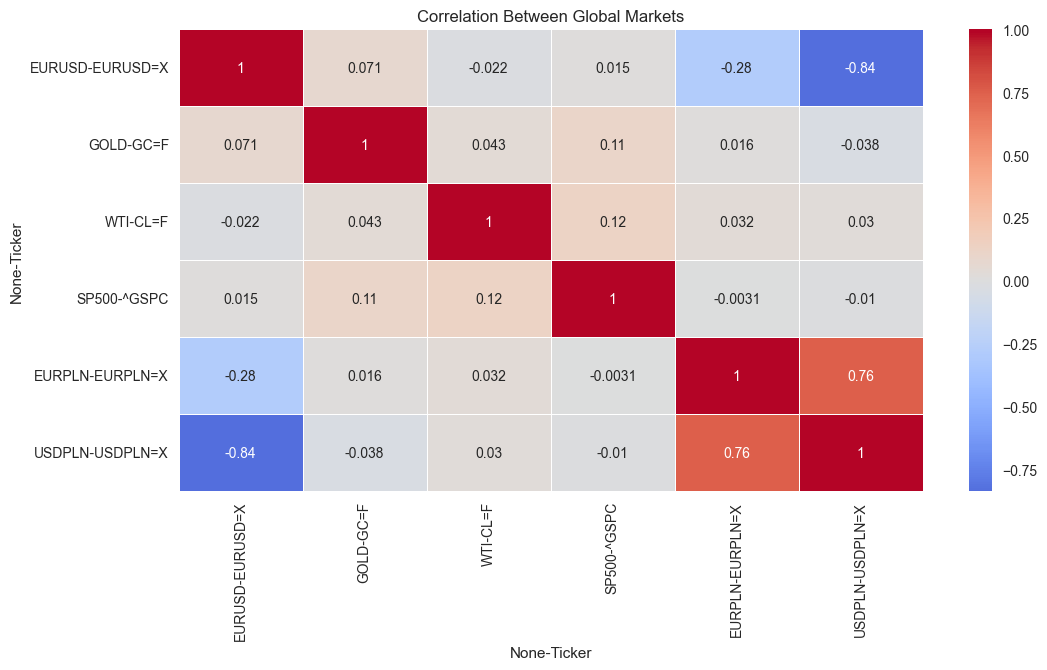

In [43]:
plt.figure(figsize=(12,6))
corr = returns.corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Between Global Markets")

plt.show()

<Figure size 1200x600 with 0 Axes>

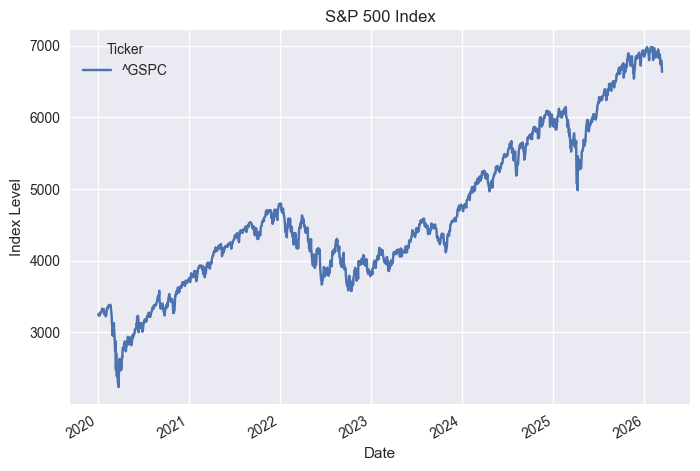

In [27]:
# Plot S&P500

plt.figure(figsize=(12,6))

prices["SP500"].plot()

plt.title("S&P 500 Index")
plt.ylabel("Index Level")
plt.xlabel("Date")

plt.grid(True)

<Figure size 1200x600 with 0 Axes>

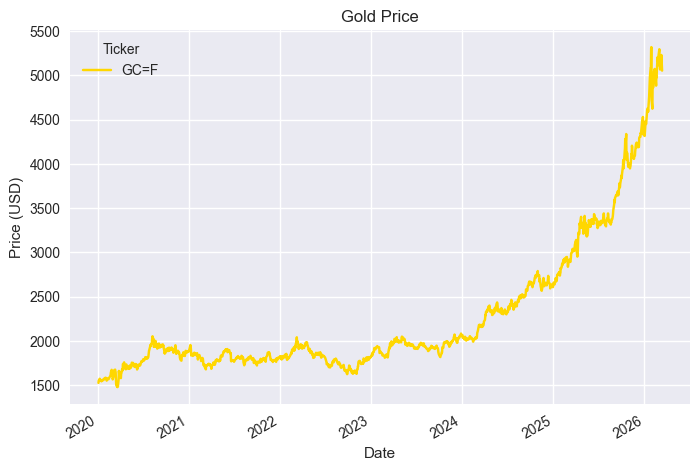

In [28]:
# Plot Gold

plt.figure(figsize=(12,6))

prices["GOLD"].plot(color="gold")

plt.title("Gold Price")
plt.ylabel("Price (USD)")
plt.xlabel("Date")

plt.grid(True)

<Figure size 1200x600 with 0 Axes>

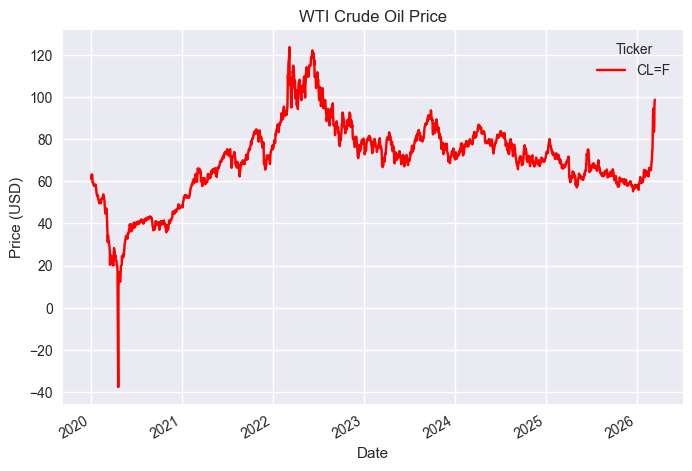

In [29]:
# Plot WTI Oil

plt.figure(figsize=(12,6))

prices["WTI"].plot(color="red")

plt.title("WTI Crude Oil Price")
plt.ylabel("Price (USD)")
plt.xlabel("Date")

plt.grid(True)

<Figure size 1200x600 with 0 Axes>

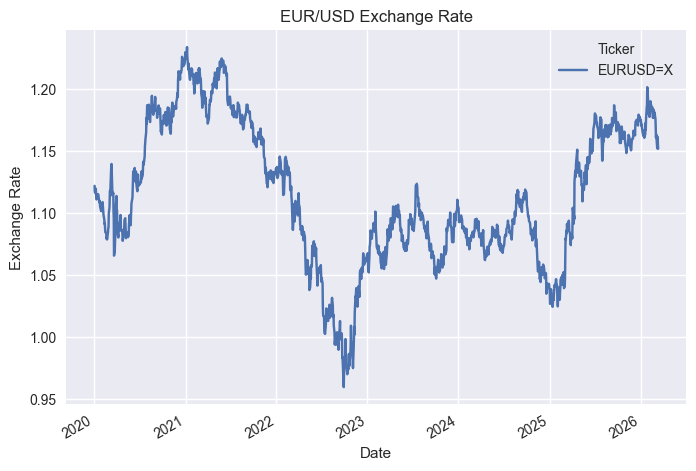

In [30]:
# Plot EUR/USD

plt.figure(figsize=(12,6))

prices["EURUSD"].plot()

plt.title("EUR/USD Exchange Rate")
plt.ylabel("Exchange Rate")
plt.xlabel("Date")

plt.grid(True)

### Global Market Dynamics Since 2020

The period since 2020 has been characterized by several major global economic shocks which strongly influenced financial markets.

**1. COVID-19 pandemic (2020)**  
In early 2020 global markets experienced a sharp shock caused by the COVID-19 pandemic.  
Economic lockdowns caused a rapid decline in economic activity and financial markets reacted with extreme volatility.  
The S&P 500 initially dropped sharply but quickly recovered due to aggressive monetary stimulus from central banks.  
Oil prices collapsed as global demand for energy fell dramatically.

**2. Monetary stimulus and recovery (2020–2021)**  
Following the pandemic shock, central banks implemented large-scale stimulus programs and very low interest rates.  
This environment supported strong growth in equity markets and contributed to rising asset prices.

**3. Inflation surge and tightening cycle (2022)**  
In 2022 global inflation accelerated significantly.  
Central banks, especially the U.S. Federal Reserve, responded with aggressive interest rate increases.  
Higher rates increased volatility across financial markets and strengthened the U.S. dollar.

**4. Energy market shock (2022)**  
Geopolitical tensions strongly affected energy markets.  
Oil prices became highly volatile as supply concerns and changing demand expectations influenced the market.

**5. Market stabilization and technological growth (2023–2025)**  
In later years financial markets gradually stabilized.  
Equity markets continued to grow, driven largely by technological innovation and strong performance of major technology companies.

Overall, the data illustrates how different asset classes react differently to global economic shocks.  
Commodities such as oil show the highest volatility, while equities reflect long-term economic growth trends.

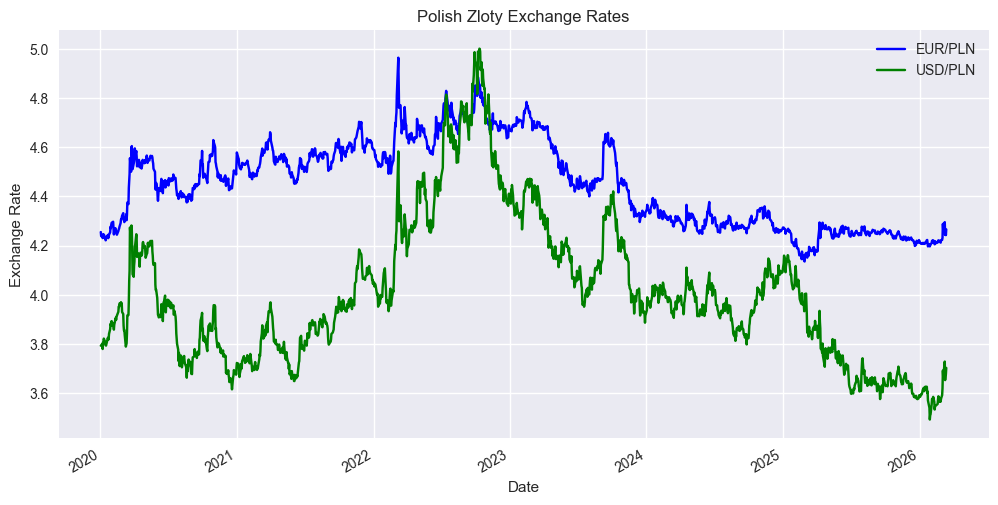

In [32]:
# Plot PLN exchange rates

plt.figure(figsize=(12,6))

prices["EURPLN"].squeeze().plot(label="EUR/PLN", color="blue")
prices["USDPLN"].squeeze().plot(label="USD/PLN", color="green")

plt.title("Polish Zloty Exchange Rates")
plt.ylabel("Exchange Rate")
plt.xlabel("Date")

plt.legend()
plt.grid(True)

### Polish Zloty Exchange Rate Dynamics

The EUR/PLN and USD/PLN exchange rates illustrate the behaviour of the Polish zloty in response to global and regional economic developments.

**1. Pandemic uncertainty (2020)**  
At the beginning of the COVID-19 pandemic the Polish zloty weakened as global financial markets moved into a risk-off environment.  
Investors shifted capital toward safer assets, causing emerging market currencies such as PLN to depreciate.

**2. Relative stability during recovery (2021)**  
During the economic recovery period the exchange rates stabilized as global economic conditions improved and financial markets regained confidence.

**3. Major depreciation in 2022**  
The most significant movement occurred in 2022 when both EUR/PLN and USD/PLN increased sharply.  
Several factors contributed to this change:

- strong appreciation of the U.S. dollar due to aggressive Federal Reserve interest rate hikes  
- the European energy crisis  
- geopolitical tensions in the region  
- high inflation in Poland and across Europe

USD/PLN briefly approached historically high levels near 5.0.

**4. Gradual recovery of the zloty (2023–2025)**  
After the peak in 2022 the Polish zloty gradually strengthened as global financial conditions stabilized, inflation pressures began to decline, and expectations for future interest rate policies changed.

The chart highlights how emerging market currencies can react strongly to global financial shocks and changes in international capital flows.

## Market Volatility

Price levels do not fully capture market risk.  
To better understand periods of financial stress we analyze rolling volatility of asset returns.

Rolling volatility measures how strongly returns fluctuate within a given time window.  
Higher volatility typically corresponds to periods of economic uncertainty or market shocks.

<Figure size 1200x600 with 0 Axes>

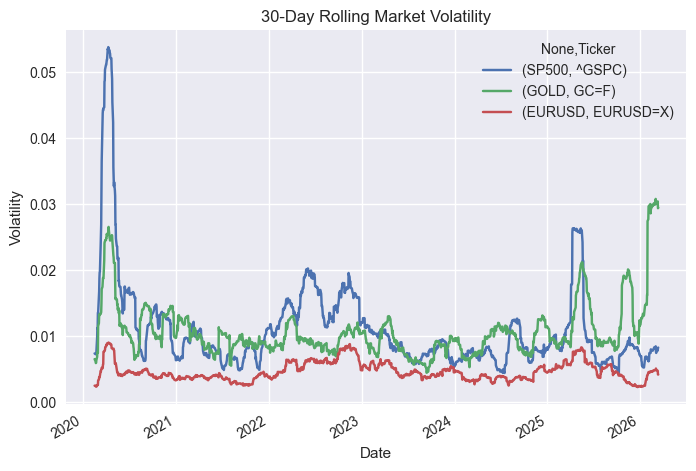

In [38]:
# Calculate 30-day rolling volatility

vol_assets = rolling_vol[["SP500","GOLD","EURUSD"]]

plt.figure(figsize=(12,6))
vol_assets.plot()

plt.title("30-Day Rolling Market Volatility")
plt.ylabel("Volatility")
plt.xlabel("Date")

plt.grid(True)

### Volatility Dynamics

Several clear volatility spikes can be observed.

**2020 – COVID-19 shock**  
Global markets experienced extreme uncertainty during the early stages of the pandemic, leading to sharp volatility across asset classes.

**2022 – Energy and inflation crisis**  
Rising inflation and aggressive monetary tightening by major central banks increased financial market instability.

**Later stabilization**  
In subsequent years volatility gradually declined as global economic conditions stabilized.

## Conclusion

The analysis demonstrates how global macroeconomic shocks influence different asset classes.

Equities reflect long-term economic growth, commodities show strong volatility during supply shocks, and exchange rates respond to global monetary policy and capital flows.

Emerging market currencies such as the Polish zloty are particularly sensitive to global financial conditions.